In [1]:
# General Imports
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Scripts 
folder_path = os.path.abspath("scripts")
sys.path.append(folder_path)

# Derivation of Column Density Maps Routine
from Derive_Density_Maps import derive_density_maps, convert_to_mass

# Visualization Tools
from visualization_tools import show_regions_with_sections, show_Minkowski_Functionals, show_sections_OrionB_vertical, visualize_Mass_Size_D_Diagrams, visualize_Mass_Size_D_Diagramm_as_One

# Minkowski Functionals
from Minkowski_Fractal_Dimension import standard_minkowski_functionals, horizontal_marching_minkowski_functionals, vertical_marching_minkowski_functionals, intercept_corrected_minkowski_functionals 

# Box Counting 
from Box_Counting_Fractal_Dimension import box_counting

# Dendogram-like Tracker
from region_tracker import track_largest_regions, save_regions_to_pickle, load_regions_from_pickle, get_region_from_fractal_dimension_mass_and_size

# Derive Density Maps
N_H2, N_H2_OA, N_H2_OB, wcs = derive_density_maps()

[12:25:48] ERROR    PARDISO solver not installed, run `pip install pypardiso`. Otherwise,          ]8;id=598965;file://c:\Users\User\anaconda3\envs\Astronomy_Env\Lib\site-packages\openpnm\utils\_workspace.py\_workspace.py]8;;\:]8;id=404544;file://c:\Users\User\anaconda3\envs\Astronomy_Env\Lib\site-packages\openpnm\utils\_workspace.py#56\56]8;;\
                    simulations will be slow. Apple M chips not supported.                                         

# **Mass-Size relation to the fractal dimension**
This Notebook explores the connection of the mass and size scaling properties with the fractal dimension. To this end, the following steps are carried out:

1. Calculate the fractal dimension of the biggest structures at each column density thresholds
2. Assess the trend compared with the general trend (when not divided into substructures)
3. Calculate mass and size of the single sub-structures
4. Assess M-L-D scaling properties 

### **Outlook**
1. Low Band Mass is too high! -> check total mass (seems fine for now. Orion B is really good, Orion A a bit off). Yet still not enough small cores...
2. Very few cores found, why? I think the issue is in this code, specifically in how the structures are found (mask)!
3. Trend doesn't make sense...
4. Save the regions in pickle again cause it takes too long

In [2]:
# Orion A

# overall, these work best for the whole region
threshold_min = 2.5e21
threshold_max = 8.5e22 # This works well when the fractal dimension is calculated for the whole region, but for the individual regions it might be good to go further down

# Minkowski
results_OA = standard_minkowski_functionals(N_H2_OA, threshold_min = threshold_min, threshold_max = threshold_max)

# Orion B

# Minkowski
results_OB = standard_minkowski_functionals(N_H2_OB, threshold_min = threshold_min, threshold_max = threshold_max)

2.868994809242656
2.8085460183953956


In [5]:
import scipy.ndimage as ndimage
from skimage.measure import perimeter
import numpy as np

import pickle 

def pca_major_axis(region_coords):
    """
    Computes the major axis length of a structure using PCA.
    The major axis is the square root of the largest eigenvalue of the covariance matrix.
    """
    if len(region_coords) < 2:
        return 0  # If only one pixel, size is zero

    # Center the coordinates
    centered_coords = region_coords - np.mean(region_coords, axis=0)

    # Compute covariance matrix and its eigenvalues
    cov_matrix = np.cov(centered_coords, rowvar=False)
    eigenvalues, _ = np.linalg.eigh(cov_matrix)

    # The largest eigenvalue corresponds to the major axis squared
    major_axis = 2 * np.sqrt(np.max(eigenvalues))  # Factor 2 to approximate full length

    return major_axis

def calculate_mass_and_size(region_mask, M_H2, pc_per_px):
    """
    Calculate the mass and the major axis of a structure using PCA.
    - Mass: Summed pixel values converted to solar masses.
    - Size: Major axis computed from PCA eigenvalues.
    """
    # Compute total mass
    mass = np.sum(M_H2[region_mask]) # * cm2_per_px 

    # Find structure coordinates
    region_coords = np.column_stack(np.where(region_mask))

    if len(region_coords) == 0:
        return mass, 0  # If no region is found, return zero size

    # Compute the major axis length using PCA
    major_axis_length = pca_major_axis(region_coords)

    # Convert size to parsecs
    size_parsecs = major_axis_length * pc_per_px

    return mass, size_parsecs

def compute_fractal_dimension(region_mask):
    """
    Compute the fractal dimension of a binary region using the Perimeter-Area relation.
    
    Parameters:
        region_mask (ndarray): Boolean mask of the structure.
        
    Returns:
        float: Estimated fractal dimension.
    """
    area = np.sum(region_mask)
    
    # Compute perimeter using dilation technique
    mask_perimeter = perimeter(region_mask)

    if area > 0 and mask_perimeter > 0:
        return 2*(np.log10(mask_perimeter) / np.log10(area))
    return None  # Invalid case (avoid division errors)

def track_largest_regions_NEW(N_H2, M_H2, thresholds, pc_per_px, num_top_regions=None, min_region_size_px=50):
    """
    Extract regions at each threshold and compute their properties.
    """
    regions = {}

    for threshold in thresholds:
        mask = N_H2 >= threshold  
        labeled_regions, num_features = ndimage.label(mask)

        if num_features == 0:
            print(f"[{threshold}] No regions found.")
            continue

        region_sizes = {
            region_id: np.sum(labeled_regions == region_id)
            for region_id in range(1, num_features + 1)
        }

        # Filter by size or pick top N
        region_ids = sorted(region_sizes, key=region_sizes.get, reverse=True)
        if num_top_regions is not None:
            region_ids = region_ids[:num_top_regions]

        saved_count = 0
        for region_id in region_ids:
            size_px = region_sizes[region_id]
            if size_px < min_region_size_px:
                continue

            region_mask = labeled_regions == region_id
            fractal_dim = compute_fractal_dimension(region_mask)
            mass, size = calculate_mass_and_size(region_mask, M_H2, pc_per_px)

            region_key = f"{threshold}_{region_id}"
            regions[region_key] = {
                "threshold": threshold,
                "fractal_dimension": fractal_dim,
                "mass": mass,
                "size": size,
                "region_mask": region_mask
            }
            saved_count += 1

        print(f"[{threshold}] Found {num_features} regions, saved {saved_count}.")

    return regions

In [6]:
# Dendograms-like approach to retrieve regions
pixel_scale = 0.00417
distance = 412 
radians = 180/np.pi # conversion factor: rad in deg
rad_per_px = pixel_scale/radians
pc_per_px = np.sin(rad_per_px)*distance

M_H2_OA = convert_to_mass(N_H2_OA)

thresholds = np.logspace(np.log10(threshold_min), np.log10(threshold_max), 100) 

if os.path.exists("top_regions_data_OA.pkl"):
    top_regions_data_OA = load_regions_from_pickle("top_regions_data_OA.pkl")
else:
    top_regions_data_OA = track_largest_regions_NEW(N_H2_OA, M_H2_OA, thresholds, pc_per_px, num_top_regions=15, min_region_size_px=10)
    # save_regions_to_pickle(top_regions_data_OA, "top_regions_data_OA.pkl")

# Plot fractal dimensions for each threshold
thresholds = np.unique([region_data["threshold"] for region_data in top_regions_data_OA.values()])

plt.figure(figsize=(14, 8))

average_fractal_dimensions = []

for i, threshold in enumerate(thresholds):
    fractal_dimensions = [
        region_data["fractal_dimension"]
        for region_data in top_regions_data_OA.values()
        if region_data["threshold"] == threshold
    ]
    plt.scatter(
        [threshold] * len(fractal_dimensions),
        fractal_dimensions,
        color="black"
    )
    if fractal_dimensions:
        average_fractal_dimensions.append(np.mean(fractal_dimensions))
    else:
        average_fractal_dimensions.append(np.nan)

plt.scatter(thresholds, average_fractal_dimensions, color='red', label="Average Fractal Dimension")

thresholds_full = np.logspace(np.log10(2.5e21), np.log10(8.5e22), 100)
plt.scatter(thresholds_full, results_OA["fractal_dimension"], label="Whole Region")

plt.xscale("log")
plt.xlabel("Threshold")
plt.ylabel("Fractal Dimension")
plt.title("Fractal Dimension vs. Threshold for Top Regions in Orion A", fontweight='bold')
plt.legend()
plt.show()

[2.4999999999999995e+21] Found 801 regions, saved 15.
[2.5906544706295043e+21] Found 764 regions, saved 15.
[2.6845962344770563e+21] Found 635 regions, saved 15.
[2.781944494673271e+21] Found 630 regions, saved 15.
[2.88282277686738e+21] Found 525 regions, saved 15.
[2.987359085969617e+21] Found 528 regions, saved 15.
[3.095686068577144e+21] Found 472 regions, saved 15.
[3.2079411812899425e+21] Found 448 regions, saved 15.
[3.3242668651301144e+21] Found 457 regions, saved 15.
[3.4448107262859726e+21] Found 407 regions, saved 15.
[3.569725723410091e+21] Found 375 regions, saved 15.
[3.6991703617093994e+21] Found 392 regions, saved 15.
[3.833308894073048e+21] Found 404 regions, saved 15.
[3.972311529493674e+21] Found 358 regions, saved 15.
[4.1163546490463993e+21] Found 333 regions, saved 15.
[4.2656210296994414e+21] Found 324 regions, saved 15.
[4.4203000762408365e+21] Found 275 regions, saved 15.
[4.5805880616149063e+21] Found 274 regions, saved 15.
[4.746688375973919e+21] Found 285 re

KeyboardInterrupt: 

[2.4999999999999995e+21] Found 788 regions, saved 15.
[2.5906544706295043e+21] Found 692 regions, saved 15.
[2.6845962344770563e+21] Found 695 regions, saved 15.
[2.781944494673271e+21] Found 662 regions, saved 15.
[2.88282277686738e+21] Found 592 regions, saved 15.
[2.987359085969617e+21] Found 514 regions, saved 15.
[3.095686068577144e+21] Found 532 regions, saved 15.
[3.2079411812899425e+21] Found 537 regions, saved 15.
[3.3242668651301144e+21] Found 508 regions, saved 15.
[3.4448107262859726e+21] Found 485 regions, saved 15.
[3.569725723410091e+21] Found 422 regions, saved 15.
[3.6991703617093994e+21] Found 420 regions, saved 15.
[3.833308894073048e+21] Found 393 regions, saved 15.
[3.972311529493674e+21] Found 352 regions, saved 15.
[4.1163546490463993e+21] Found 326 regions, saved 15.
[4.2656210296994414e+21] Found 284 regions, saved 15.
[4.4203000762408365e+21] Found 256 regions, saved 15.
[4.5805880616149063e+21] Found 258 regions, saved 15.
[4.746688375973919e+21] Found 232 re

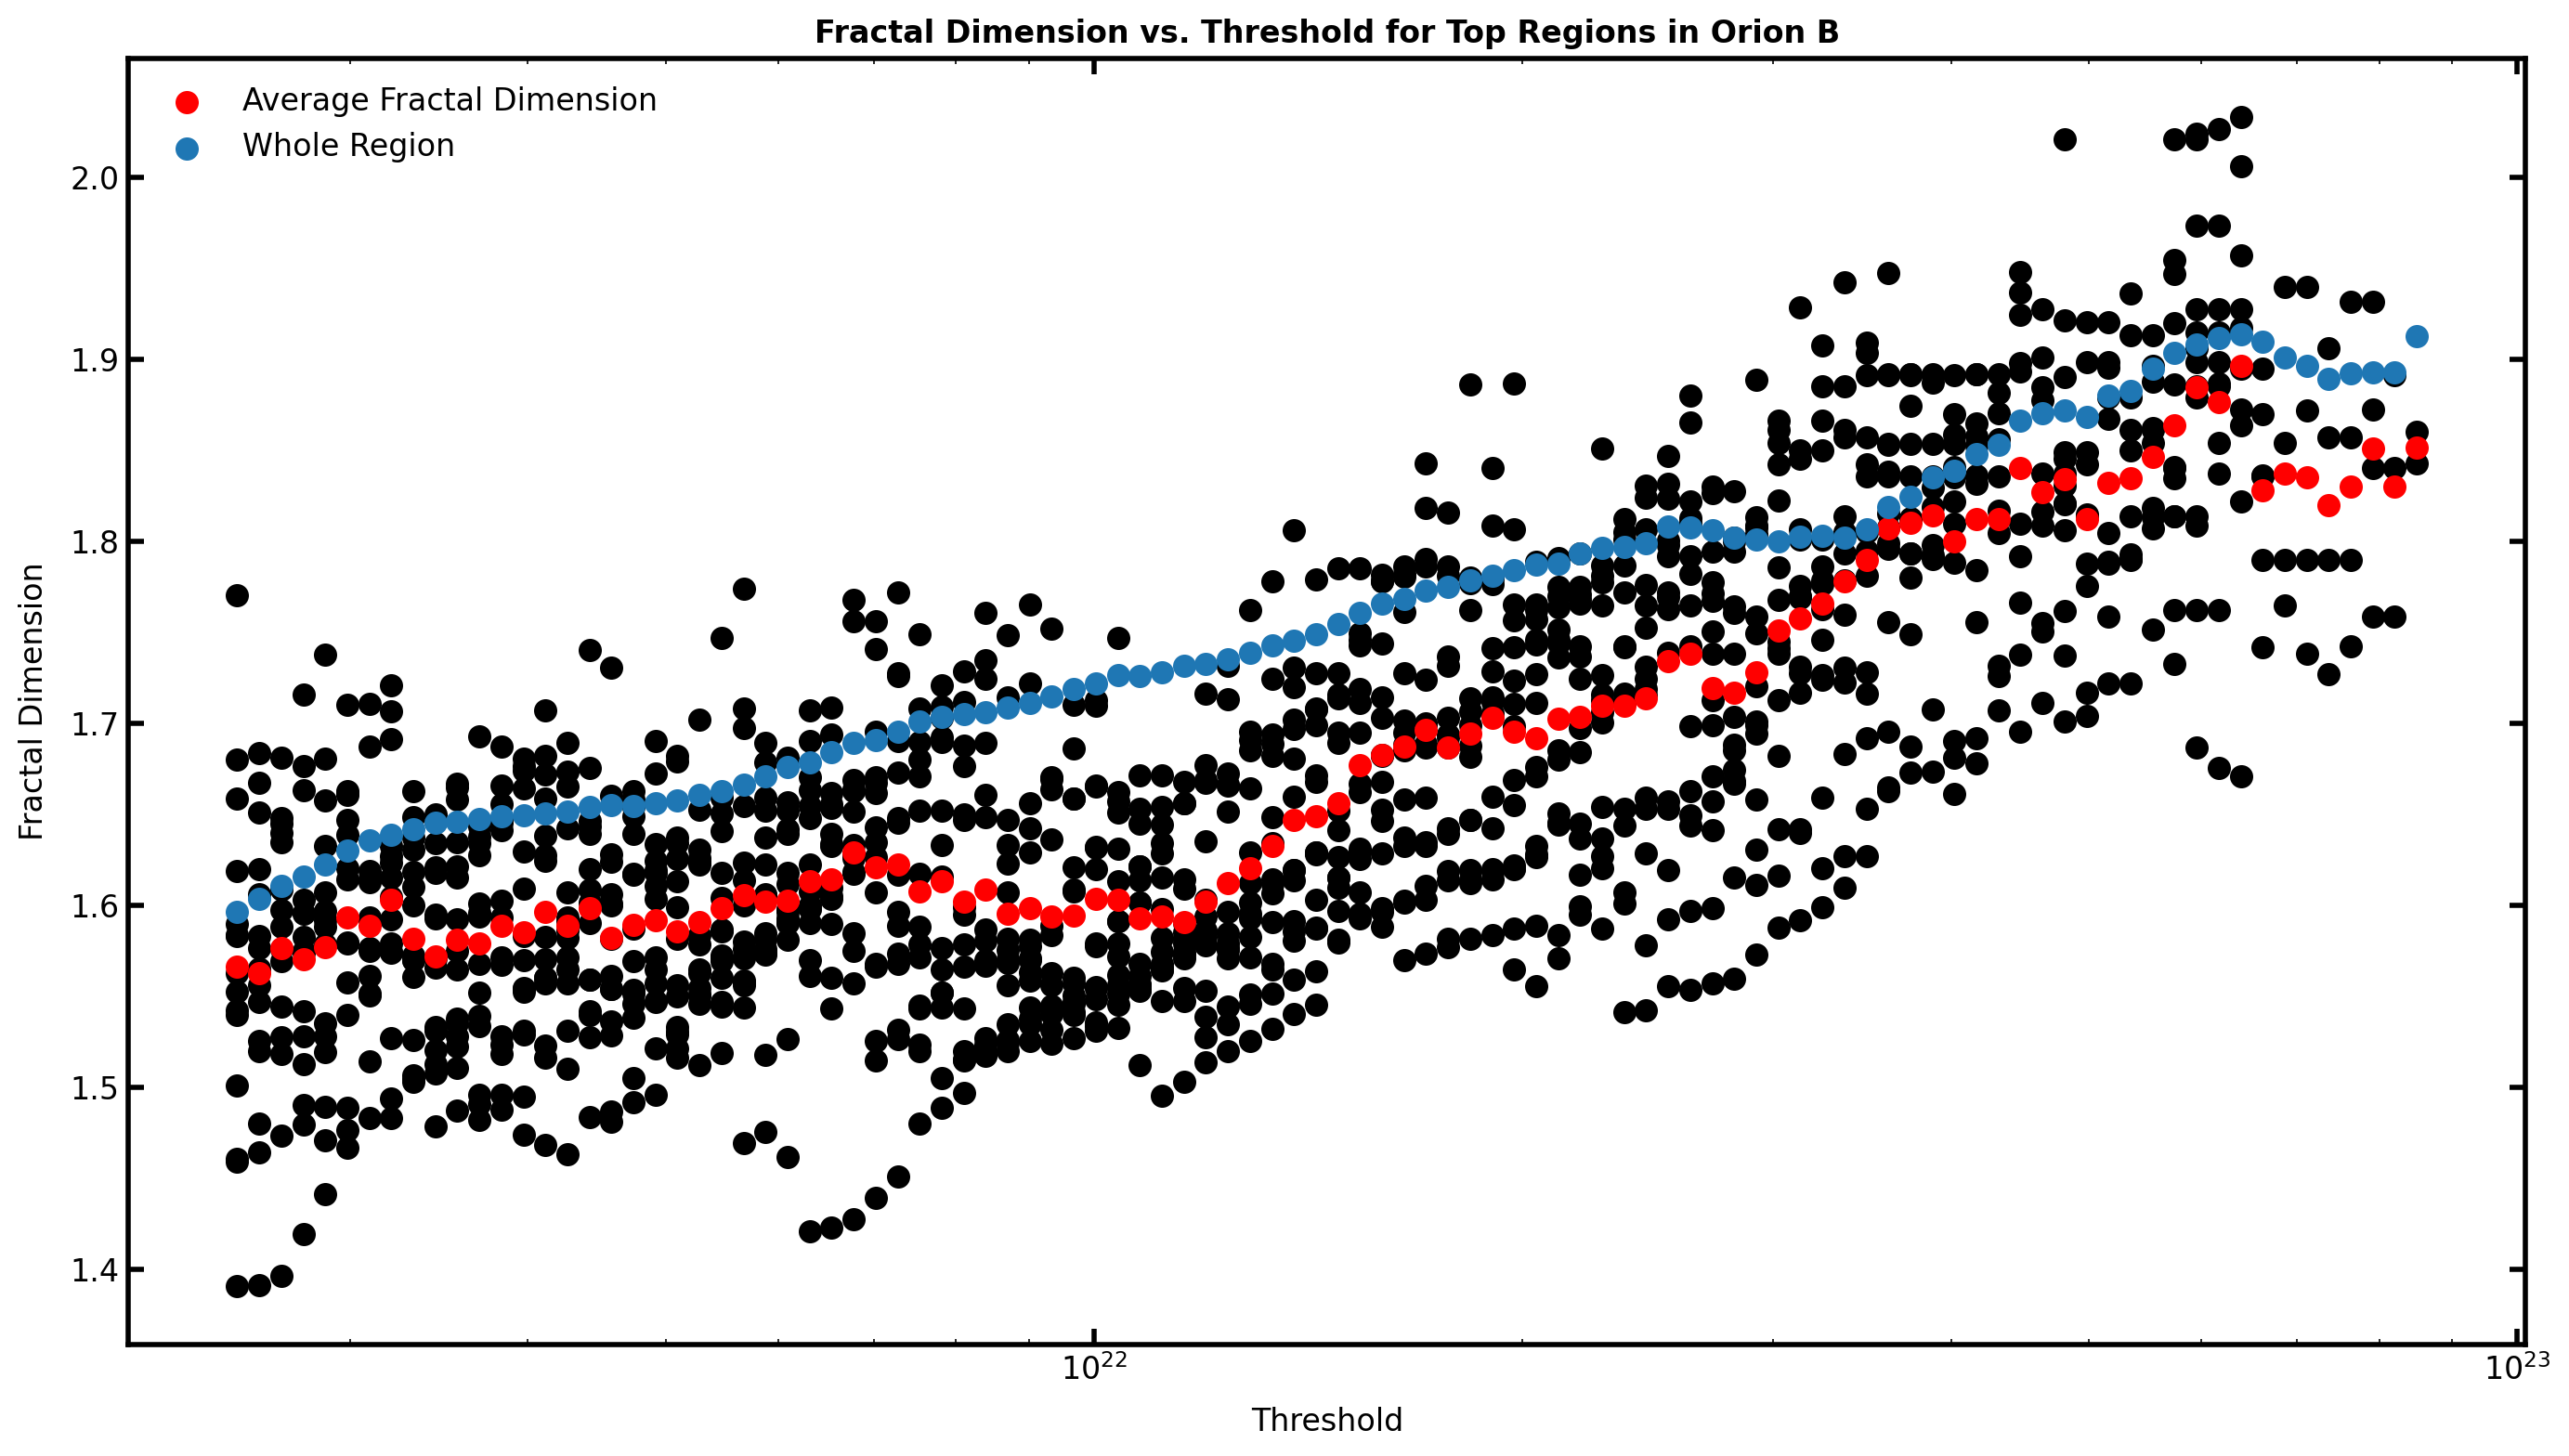

In [ ]:
# Dendograms-like approach to retrieve regions

pixel_scale = 0.00417
distance = 412 
radians = 180/np.pi #conversion factor: rad in deg
rad_per_px = pixel_scale/radians
pc_per_px = np.sin(rad_per_px)*distance

M_H2_OB = convert_to_mass(N_H2_OB)

thresholds = np.logspace(np.log10(threshold_min), np.log10(threshold_max), 100) 

if os.path.exists("top_regions_data_OB.pkl"):
    top_regions_data_OB = load_regions_from_pickle("top_regions_data_OB.pkl")
else:
    top_regions_data_OB = track_largest_regions_NEW(N_H2_OB, M_H2_OB, thresholds, pc_per_px, num_top_regions=15, min_region_size_px=10)
    # save_regions_to_pickle(top_regions_data_OA, "top_regions_data_OA.pkl")

# Plot fractal dimensions for each threshold
thresholds = np.unique([region_data["threshold"] for region_data in top_regions_data_OB.values()])

plt.figure(figsize=(14, 8))

average_fractal_dimensions = []

for i, threshold in enumerate(thresholds):
    fractal_dimensions = [
        region_data["fractal_dimension"]
        for region_data in top_regions_data_OB.values()
        if region_data["threshold"] == threshold
    ]
    plt.scatter(
        [threshold] * len(fractal_dimensions),
        fractal_dimensions,
        color="black"
    )
    if fractal_dimensions:
        average_fractal_dimensions.append(np.mean(fractal_dimensions))
    else:
        average_fractal_dimensions.append(np.nan)

plt.scatter(thresholds, average_fractal_dimensions, color='red', label="Average Fractal Dimension")

thresholds_full = np.logspace(np.log10(2.5e21), np.log10(8.5e22), 100)
plt.scatter(thresholds_full, results_OB["fractal_dimension"], label="Whole Region")

plt.xscale("log")
plt.xlabel("Threshold")
plt.ylabel("Fractal Dimension")
plt.title("Fractal Dimension vs. Threshold for Top Regions in Orion B", fontweight='bold')
plt.legend()
plt.show()

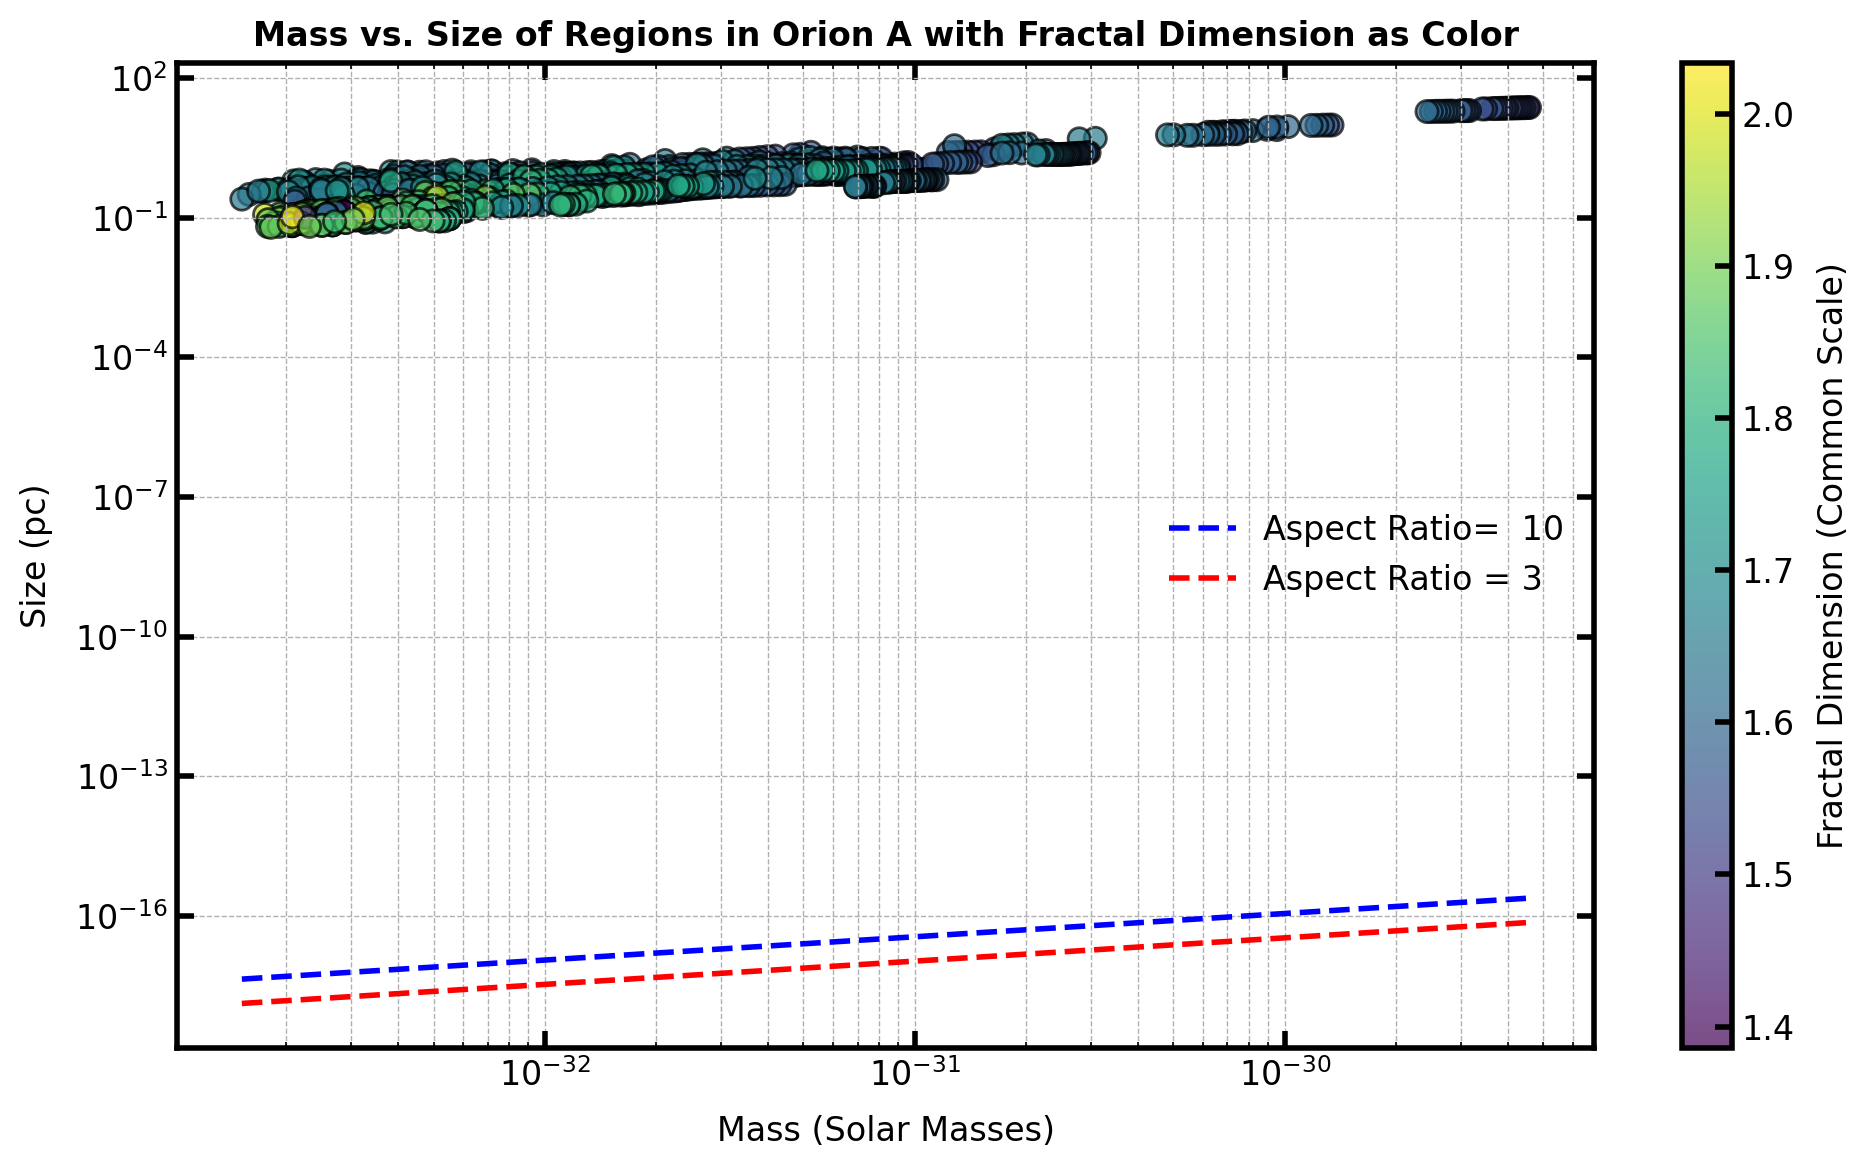

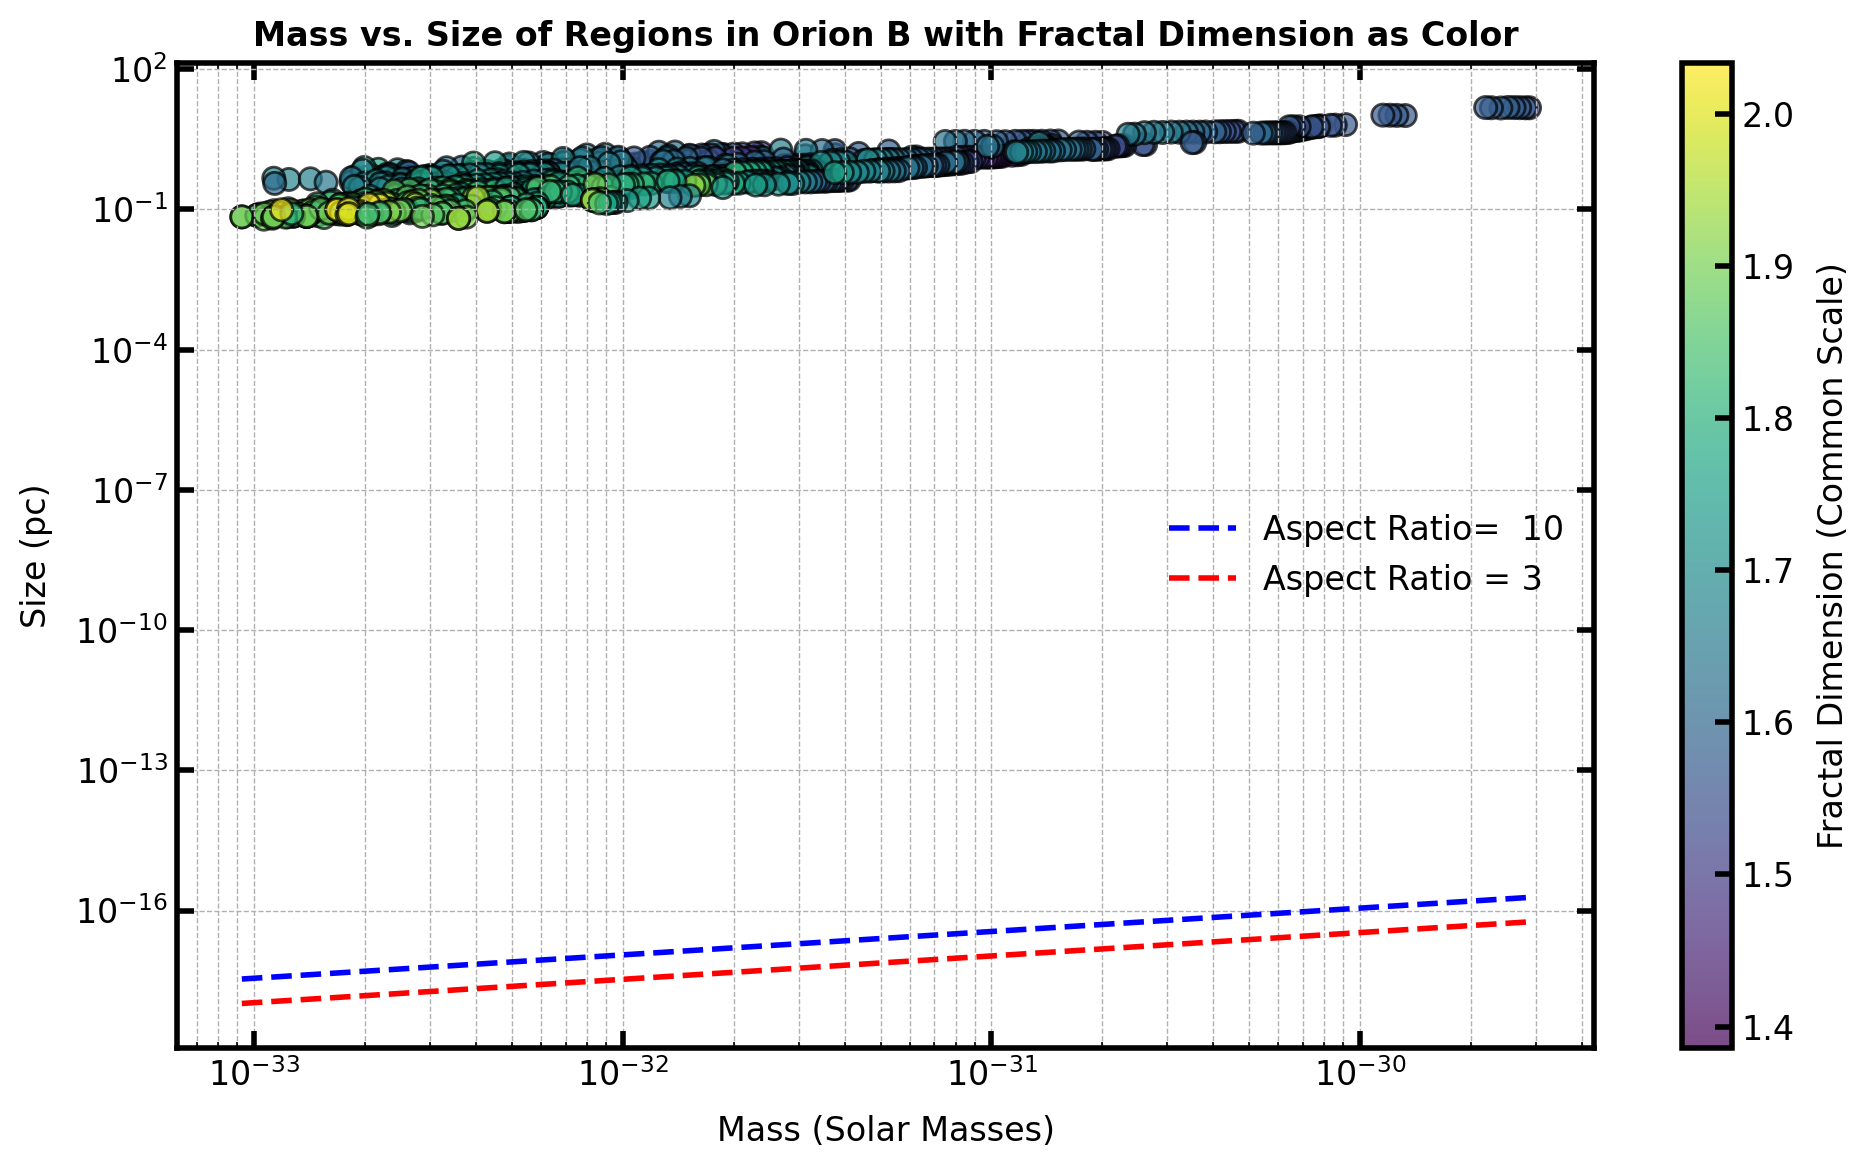

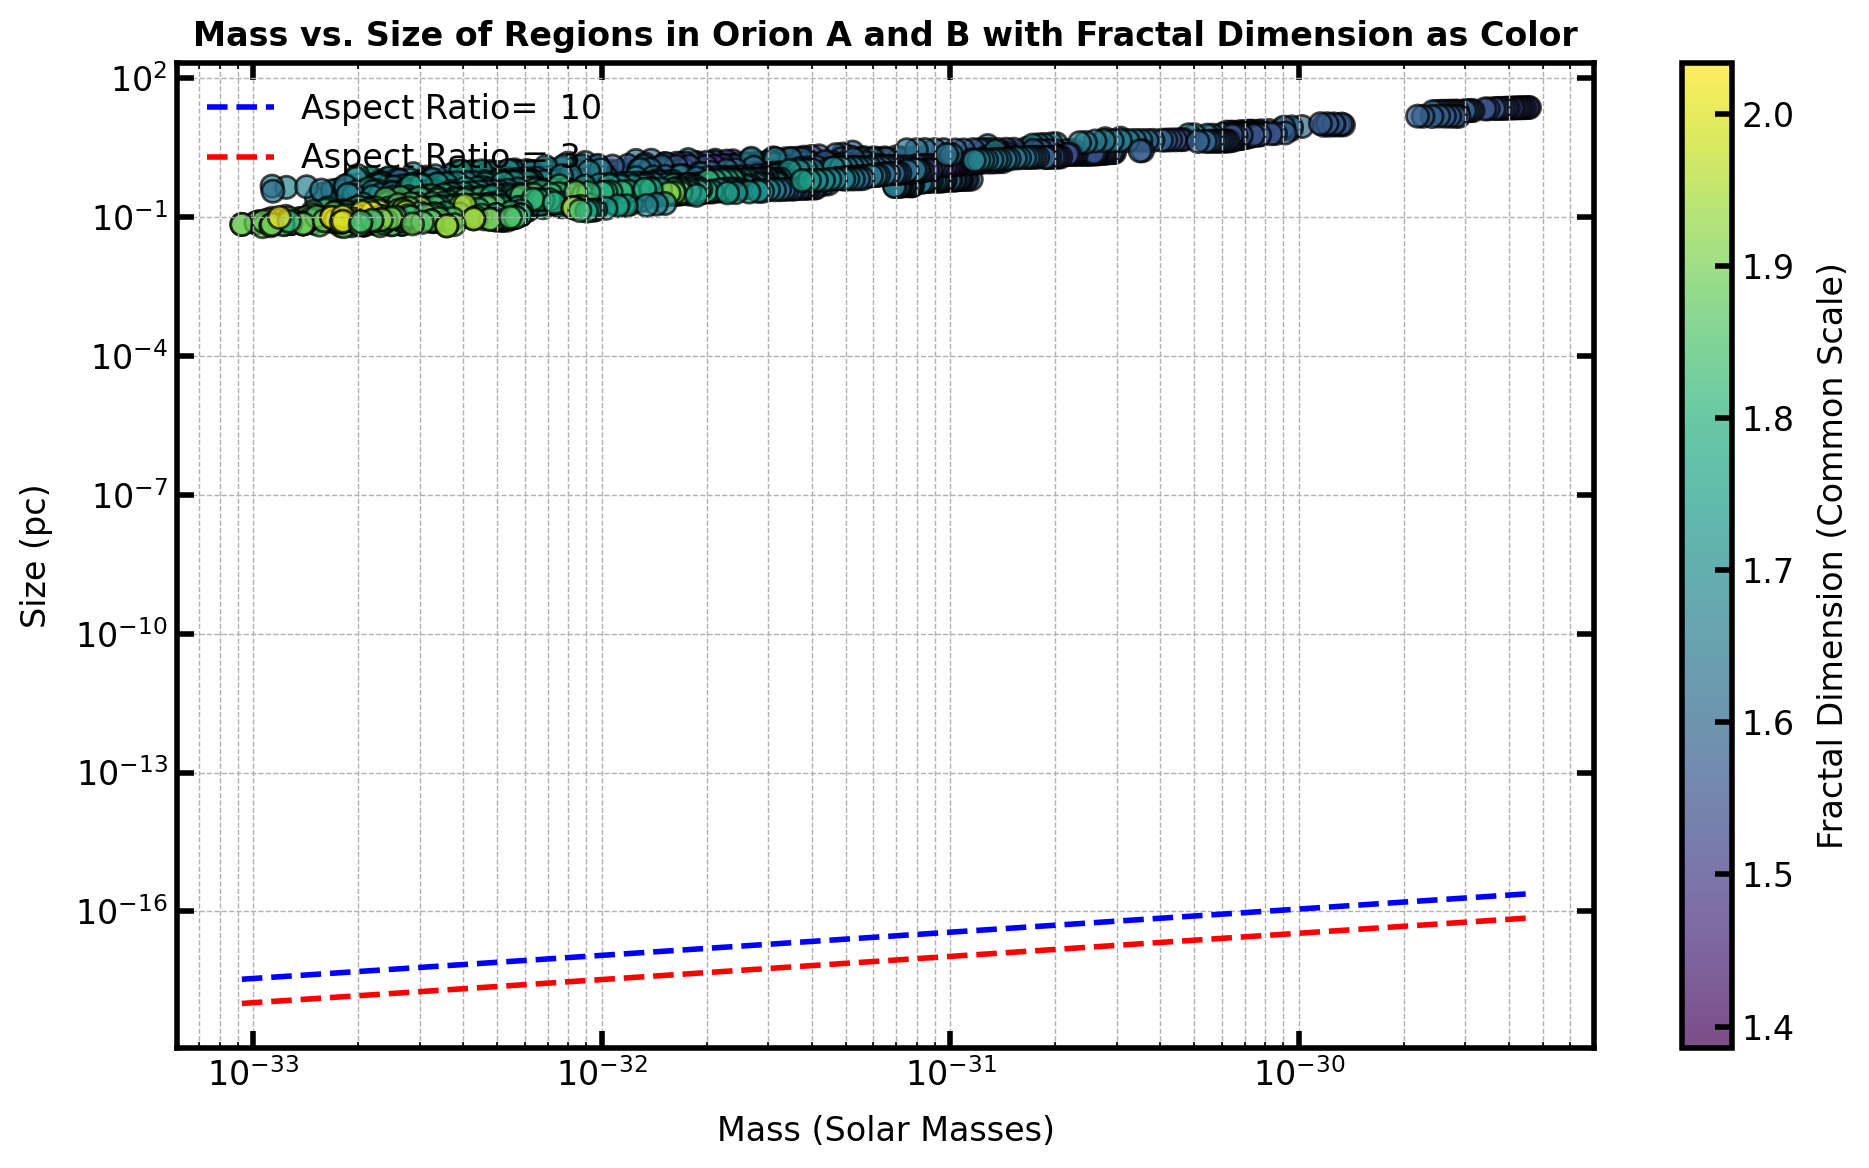

In [ ]:
# Extract fractal dimensions, sizes, and masses for Orion A and B
fractal_dims_OA = [region_data["fractal_dimension"] for region_data in top_regions_data_OA.values()]
sizes_OA = [region_data["size"] for region_data in top_regions_data_OA.values()]
masses_OA = [region_data["mass"] for region_data in top_regions_data_OA.values()]

fractal_dims_OB = [region_data["fractal_dimension"] for region_data in top_regions_data_OB.values()]
sizes_OB = [region_data["size"] for region_data in top_regions_data_OB.values()]
masses_OB = [region_data["mass"] for region_data in top_regions_data_OB.values()]

# Single Regions
visualize_Mass_Size_D_Diagrams(fractal_dims_OA, fractal_dims_OB, masses_OA, masses_OB, sizes_OA, sizes_OB)

# All
visualize_Mass_Size_D_Diagramm_as_One(fractal_dims_OA, fractal_dims_OB, masses_OA, masses_OB, sizes_OA, sizes_OB)

## **Using dendrograms**

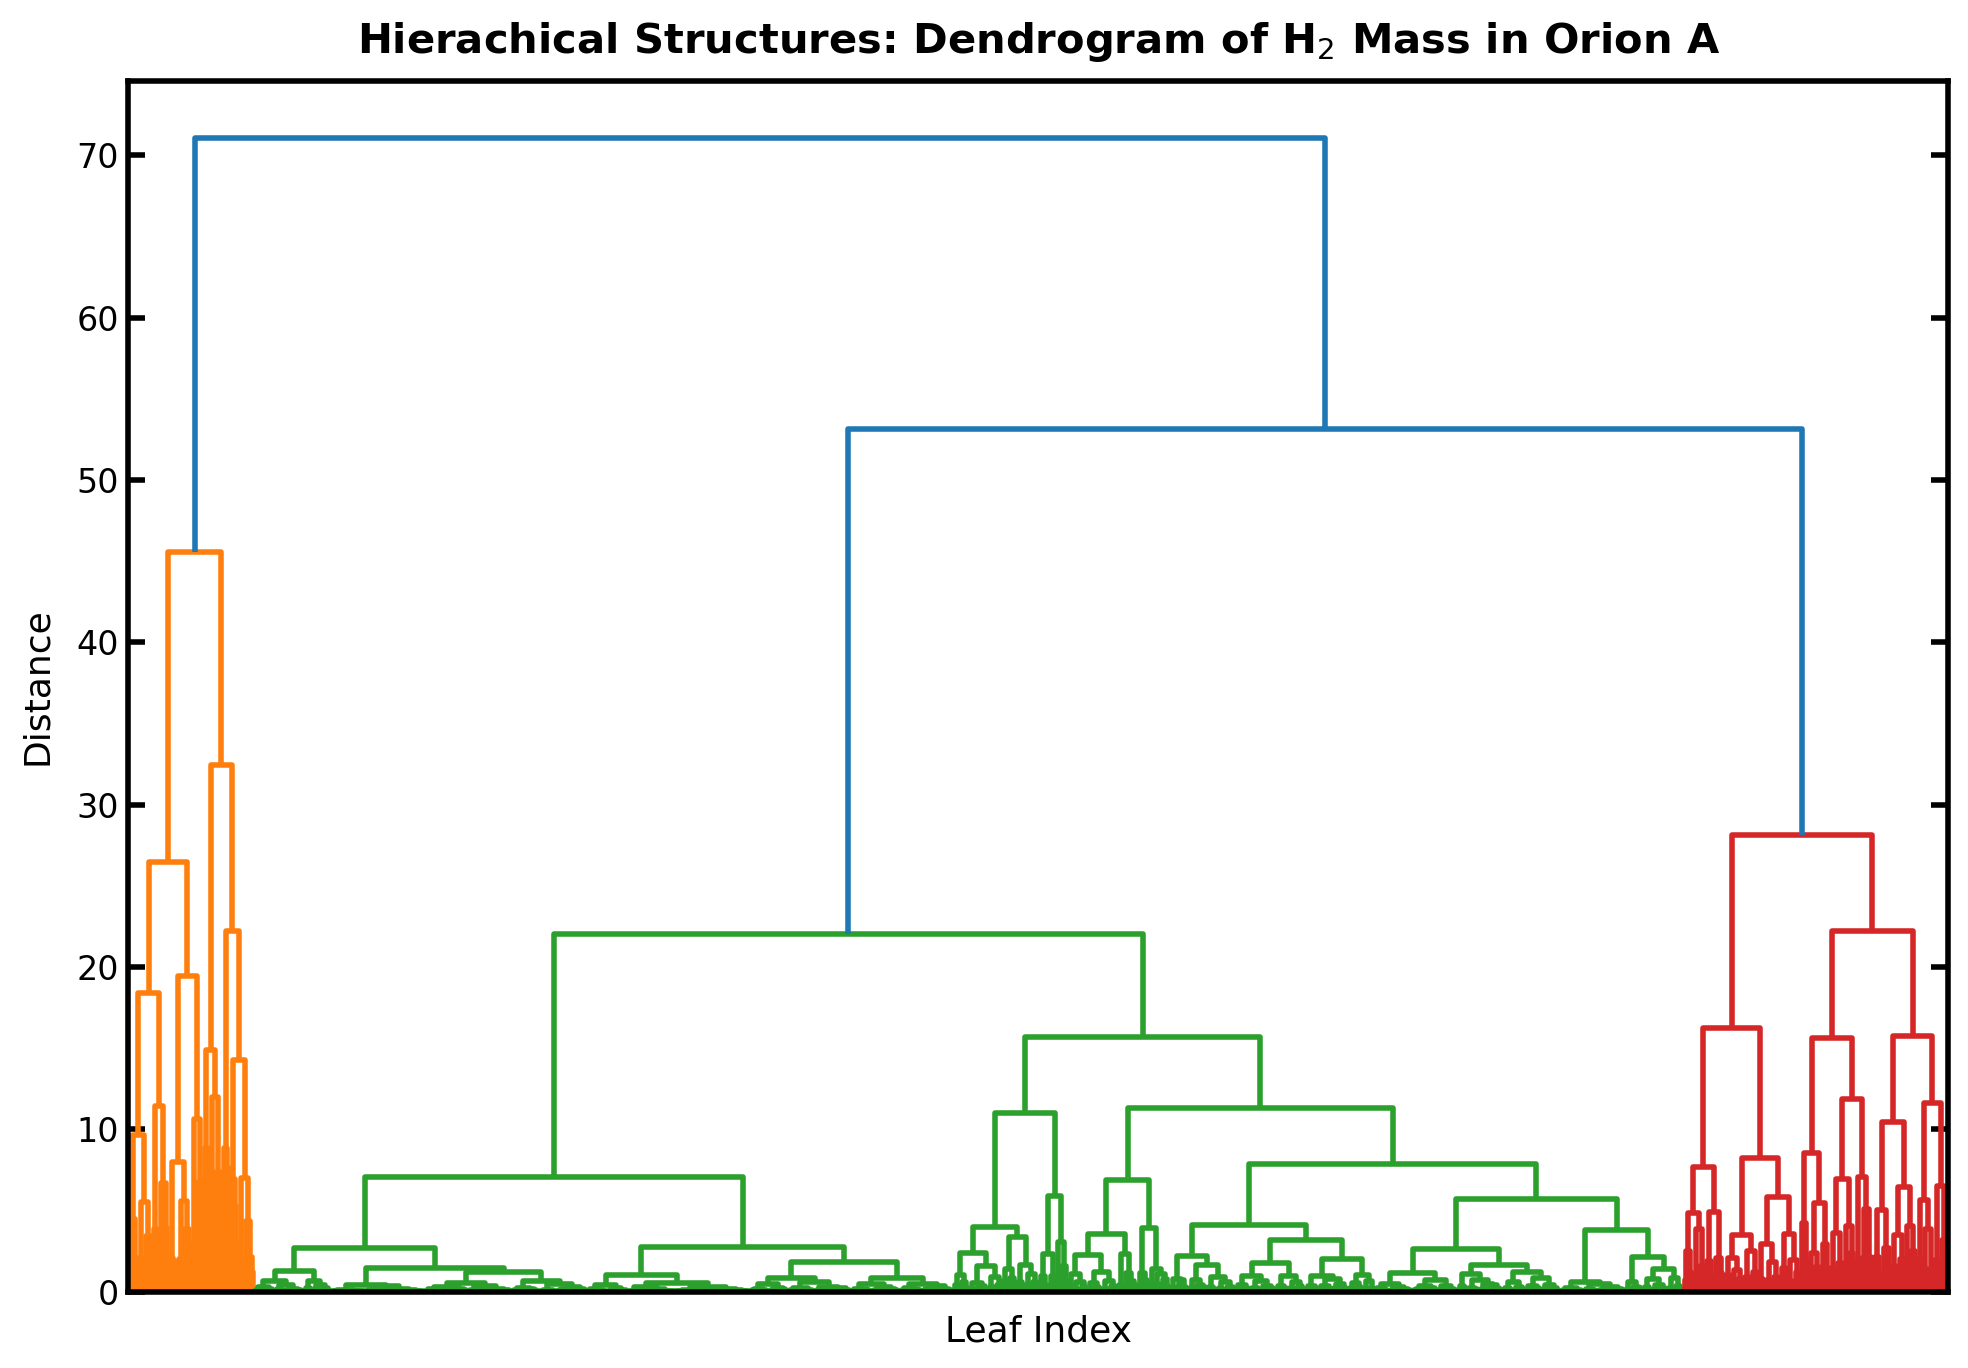

In [2]:
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt
import numpy as np

M_H2_OA = convert_to_mass(N_H2_OA)

# Perform hierarchical clustering
linkage_matrix = sch.linkage(M_H2_OA, method='ward')

# Create the dendrogram
plt.figure(figsize=(10, 7))
dendrogram = sch.dendrogram(linkage_matrix, no_labels=True)  # Remove default labels

# Customize the plot
plt.title("Hierachical Structures: Dendrogram of H$_2$ Mass in Orion A", fontweight="bold", fontsize=15, pad=10)
plt.xlabel("Leaf Index", fontsize=13)
plt.ylabel("Distance", fontsize=13)

# Set custom x-ticks: display fewer ticks by setting a stride
num_ticks = 0  # Number of ticks you want to show
xtick_positions = np.linspace(0, len(linkage_matrix), num_ticks, dtype=int)
plt.xticks(xtick_positions, labels=xtick_positions, fontsize=10)  # Set custom tick labels

plt.show()

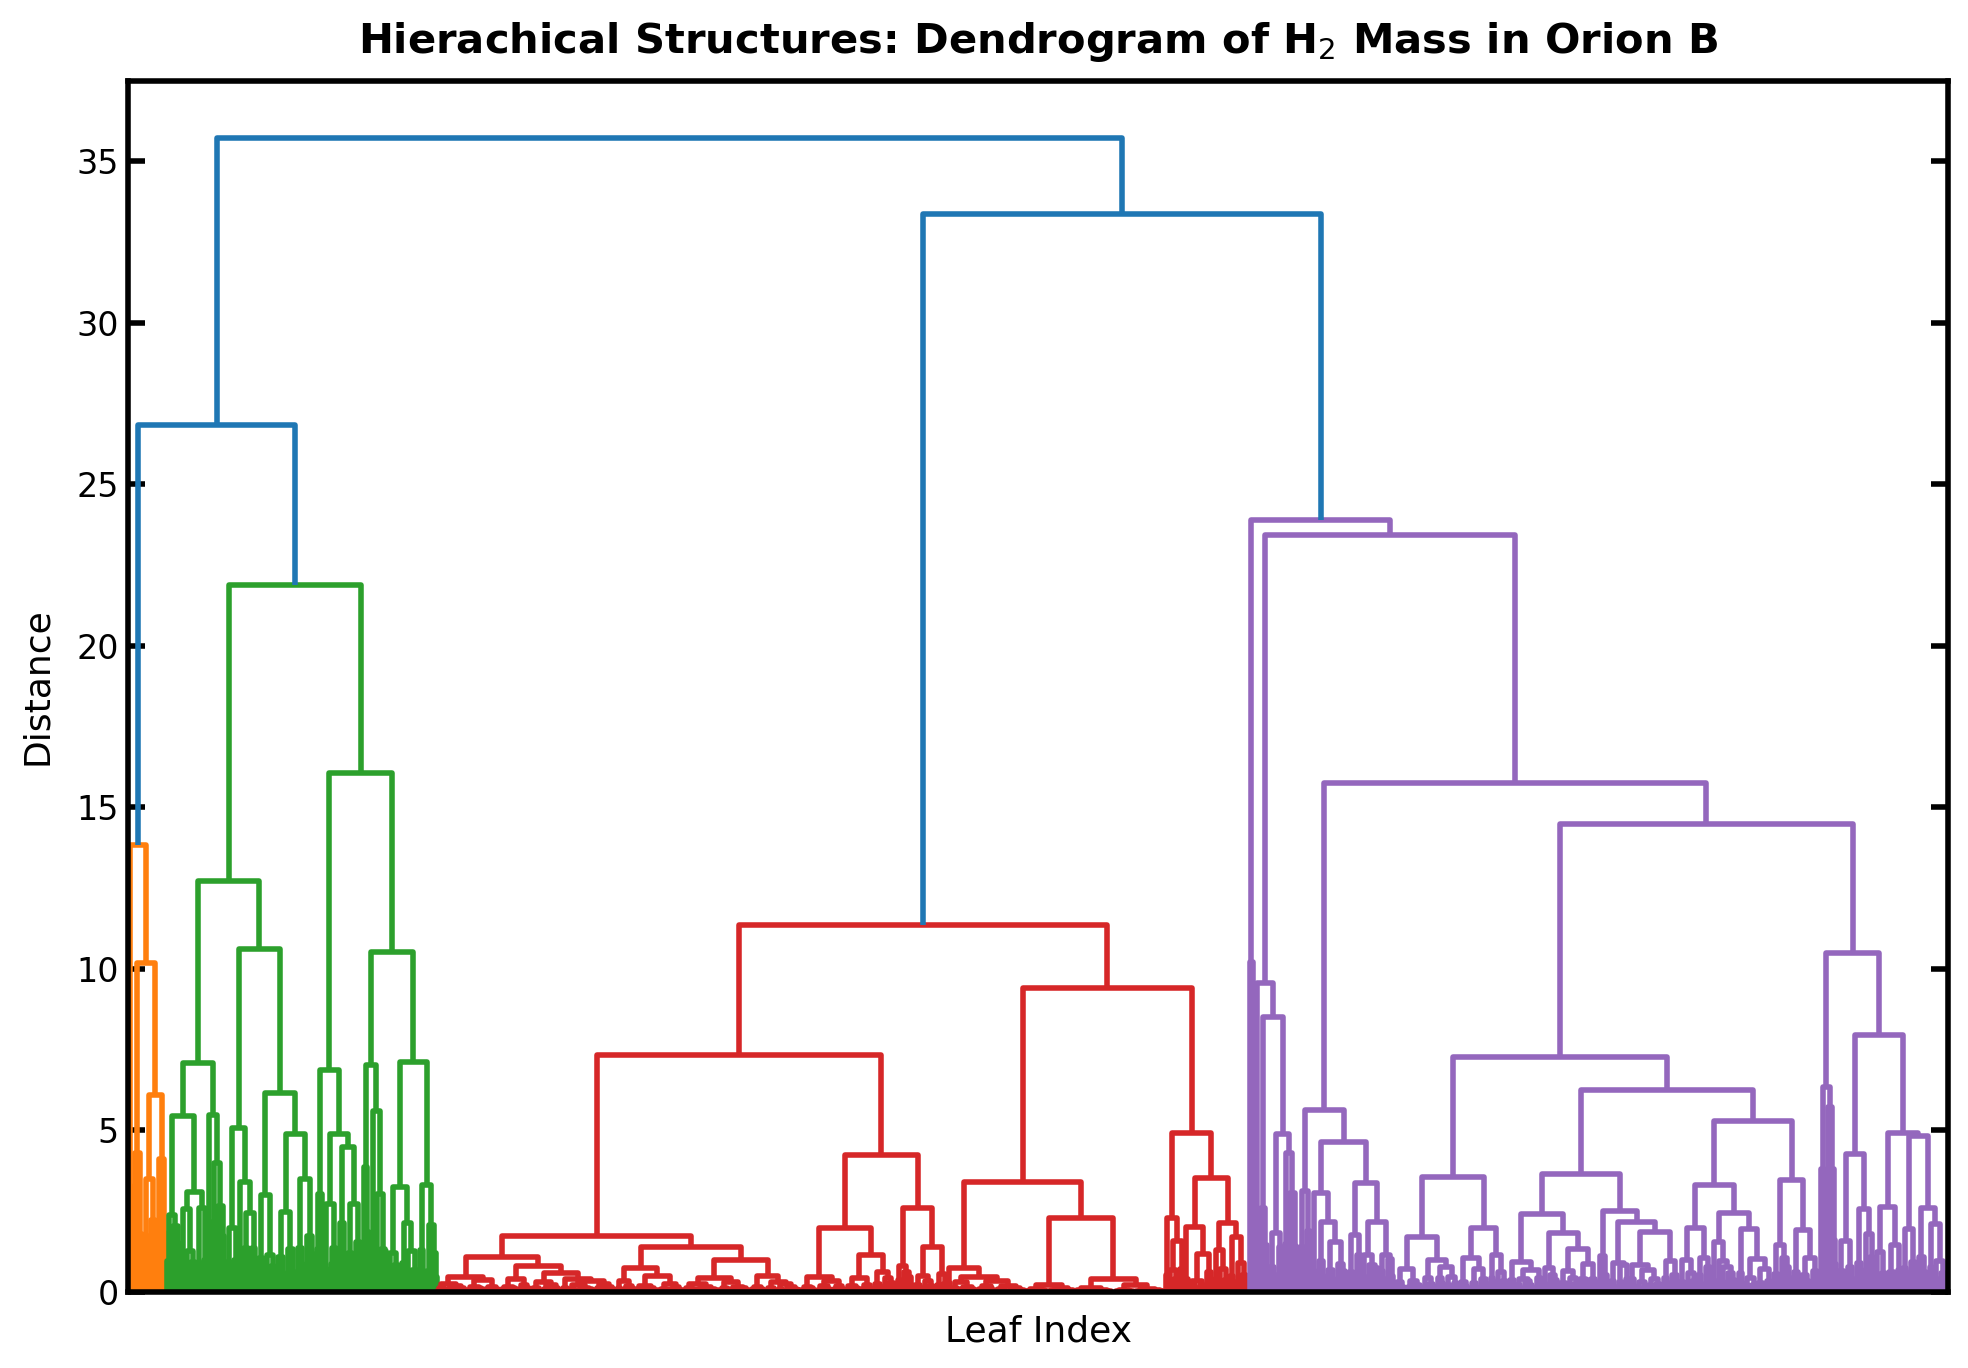

In [3]:
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt
import numpy as np

M_H2_OB = convert_to_mass(N_H2_OB)

# Perform hierarchical clustering
linkage_matrix = sch.linkage(M_H2_OB, method='ward')

# Create the dendrogram
plt.figure(figsize=(10, 7))
dendrogram = sch.dendrogram(linkage_matrix, no_labels=True)  # Remove default labels

# Customize the plot
plt.title("Hierachical Structures: Dendrogram of H$_2$ Mass in Orion B", fontweight="bold", fontsize=15, pad=10)
plt.xlabel("Leaf Index", fontsize=13)
plt.ylabel("Distance", fontsize=13)

# Set custom x-ticks: display fewer ticks by setting a stride
num_ticks = 0  # Number of ticks you want to show
xtick_positions = np.linspace(0, len(linkage_matrix), num_ticks, dtype=int)
plt.xticks(xtick_positions, labels=xtick_positions, fontsize=10)  # Set custom tick labels

plt.show()


In [18]:
print(np.min(M_H2_OA))
print(np.max(M_H2_OA))
print(np.min(M_H2_OB))
print(np.max(M_H2_OB))

min_value = np.percentile(M_H2_OA, 90)  # 2nd percentile
max_value = np.percentile(M_H2_OA, 99)  # 98th percentile

print(min_value)
print(max_value)

0.0
9.486631839285888
0.0
6.871581865299017
0.06489370803502534
0.2665351872738277


In [108]:
from scipy import ndimage
from skimage.measure import perimeter

def pca_major_axis(region_coords):
    if len(region_coords) < 2:
        return 0
    centered_coords = region_coords - np.mean(region_coords, axis=0)
    cov_matrix = np.cov(centered_coords, rowvar=False)
    eigenvalues, _ = np.linalg.eigh(cov_matrix)
    major_axis = 2 * np.sqrt(np.max(eigenvalues))
    return major_axis

pixel_scale = 0.00417
distance = 412 
radians = 180/np.pi # conversion factor: rad in deg
rad_per_px = pixel_scale/radians
pc_per_px = np.sin(rad_per_px)*distance

min_value = np.percentile(M_H2_OA, 25)  # 2nd percentile
max_value = np.percentile(M_H2_OA, 100)  # 98th percentile

thresholds = np.linspace(min_value, max_value, 100)  # Example thresholds for mass map # M_sun/cm^2

region_masses_OA = []
region_sizes_OA = []
region_fractal_dims_OA = []

for threshold in thresholds:

    print(f"\nProcessing threshold: {threshold:.2f} M☉/cm²")
    
    # Step 1: Threshold the mass map
    structure_mask = M_H2_OA > threshold

    # Step 2: Label connected regions
    labeled_array, num_features = ndimage.label(structure_mask)

    if num_features == 0:
        print("No structures found at this threshold.")
        continue

    # Step 3: Compute areas of all structures
    region_areas = []
    for i in range(1, num_features + 1):
        area = np.sum(labeled_array == i)
        region_areas.append((i, area))

    # Sort by area descending
    region_areas.sort(key=lambda x: x[1], reverse=True)

    # Keep only top 10
    top_regions = region_areas[:100]

    # Step 4: Loop through selected regions
    for region_idx, area in top_regions:
        region_mask = labeled_array == region_idx

        # Mass
        mass = np.sum(M_H2_OA[region_mask])
        region_masses_OA.append(mass)

        # Coordinates
        coords = np.argwhere(region_mask)

        # Size in pc
        size_px = pca_major_axis(coords)
        size_pc = size_px * pc_per_px
        region_sizes_OA.append(size_pc)

        # Fractal Dimension
        region_binary = region_mask.astype(np.uint8)
        perim = perimeter(region_binary)
        if area > 5 and perim > 0:
            D = 2 * (np.log10(perim) / np.log10(area))
        else:
            D = np.nan  # handle degenerate cases
        region_fractal_dims_OA.append(D)

        print(f"Structure {region_idx}: Mass = {mass:.2f} M☉, Size ≈ {size_pc:.2f} pc, Fractal Dimension D ≈ {D:.2f}")



Processing threshold: 0.01 M☉/cm²
Structure 1: Mass = 75816.16 M☉, Size ≈ 41.54 pc, Fractal Dimension D ≈ 1.44
Structure 1522: Mass = 49.79 M☉, Size ≈ 2.18 pc, Fractal Dimension D ≈ 1.44
Structure 1830: Mass = 8.23 M☉, Size ≈ 0.59 pc, Fractal Dimension D ≈ 1.45
Structure 2654: Mass = 4.78 M☉, Size ≈ 0.64 pc, Fractal Dimension D ≈ 1.53
Structure 2655: Mass = 4.71 M☉, Size ≈ 0.52 pc, Fractal Dimension D ≈ 1.56
Structure 4381: Mass = 4.13 M☉, Size ≈ 0.46 pc, Fractal Dimension D ≈ 1.82
Structure 1683: Mass = 3.40 M☉, Size ≈ 0.45 pc, Fractal Dimension D ≈ 1.50
Structure 53: Mass = 2.88 M☉, Size ≈ 0.47 pc, Fractal Dimension D ≈ 1.85
Structure 1568: Mass = 2.61 M☉, Size ≈ 0.58 pc, Fractal Dimension D ≈ 1.62
Structure 14: Mass = 2.57 M☉, Size ≈ 0.39 pc, Fractal Dimension D ≈ 1.82
Structure 4229: Mass = 2.38 M☉, Size ≈ 0.36 pc, Fractal Dimension D ≈ 1.82
Structure 2885: Mass = 2.06 M☉, Size ≈ 0.48 pc, Fractal Dimension D ≈ 1.61
Structure 198: Mass = 2.16 M☉, Size ≈ 0.52 pc, Fractal Dimension D

In [109]:
from scipy import ndimage
from skimage.measure import perimeter

# Step 3: Define PCA major axis function
def pca_major_axis(region_coords):
    if len(region_coords) < 2:
        return 0
    centered_coords = region_coords - np.mean(region_coords, axis=0)
    cov_matrix = np.cov(centered_coords, rowvar=False)
    eigenvalues, _ = np.linalg.eigh(cov_matrix)
    major_axis = 2 * np.sqrt(np.max(eigenvalues))
    return major_axis

min_value = np.percentile(M_H2_OB, 25)  # 2nd percentile
max_value = np.percentile(M_H2_OB, 100)  # 98th percentile

thresholds = np.linspace(min_value, max_value, 100)  # Example thresholds for mass map # M_sun/cm^2

pixel_scale = 0.00417
distance = 412 
radians = 180/np.pi # conversion factor: rad in deg
rad_per_px = pixel_scale/radians
pc_per_px = np.sin(rad_per_px)*distance

region_masses_OB = []
region_sizes_OB = []
region_fractal_dims_OB = []

for threshold in thresholds:

    print(f"\nProcessing threshold: {threshold:.2f} M☉/cm²")
    
    # Step 1: Threshold the mass map
    structure_mask = M_H2_OB > threshold

    # Step 2: Label connected regions
    labeled_array, num_features = ndimage.label(structure_mask)

    if num_features == 0:
        print("No structures found at this threshold.")
        continue

    # Step 3: Compute areas of all structures
    region_areas = []
    for i in range(1, num_features + 1):
        area = np.sum(labeled_array == i)
        region_areas.append((i, area))

    # Sort by area descending
    region_areas.sort(key=lambda x: x[1], reverse=True)

    # Keep only top 10
    top_regions = region_areas[:100]

    # Step 4: Loop through selected regions
    for region_idx, area in top_regions:
        region_mask = labeled_array == region_idx

        # Mass
        mass = np.sum(M_H2_OB[region_mask])
        region_masses_OB.append(mass)

        # Coordinates
        coords = np.argwhere(region_mask)

        # Size in pc
        size_px = pca_major_axis(coords)
        size_pc = size_px * pc_per_px
        region_sizes_OB.append(size_pc)

        # Fractal Dimension
        region_binary = region_mask.astype(np.uint8)
        perim = perimeter(region_binary)
        if area > 5 and perim > 0:
            D = 2 * (np.log10(perim) / np.log10(area))
        else:
            D = np.nan  # handle degenerate cases
        region_fractal_dims_OB.append(D)

        print(f"Structure {region_idx}: Mass = {mass:.2f} M☉, Size ≈ {size_pc:.2f} pc, Fractal Dimension D ≈ {D:.2f}")



Processing threshold: 0.00 M☉/cm²
Structure 1: Mass = 54867.97 M☉, Size ≈ 24.60 pc, Fractal Dimension D ≈ 1.27

Processing threshold: 0.07 M☉/cm²
Structure 5: Mass = 10774.38 M☉, Size ≈ 10.28 pc, Fractal Dimension D ≈ 1.57
Structure 285: Mass = 6572.11 M☉, Size ≈ 6.01 pc, Fractal Dimension D ≈ 1.53
Structure 141: Mass = 268.14 M☉, Size ≈ 1.41 pc, Fractal Dimension D ≈ 1.63
Structure 82: Mass = 201.91 M☉, Size ≈ 1.32 pc, Fractal Dimension D ≈ 1.48
Structure 13: Mass = 101.72 M☉, Size ≈ 1.30 pc, Fractal Dimension D ≈ 1.57
Structure 286: Mass = 66.86 M☉, Size ≈ 0.77 pc, Fractal Dimension D ≈ 1.59
Structure 19: Mass = 59.81 M☉, Size ≈ 1.10 pc, Fractal Dimension D ≈ 1.62
Structure 72: Mass = 63.37 M☉, Size ≈ 0.59 pc, Fractal Dimension D ≈ 1.51
Structure 3: Mass = 55.82 M☉, Size ≈ 0.55 pc, Fractal Dimension D ≈ 1.51
Structure 247: Mass = 45.05 M☉, Size ≈ 0.62 pc, Fractal Dimension D ≈ 1.59
Structure 77: Mass = 47.51 M☉, Size ≈ 0.49 pc, Fractal Dimension D ≈ 1.52
Structure 302: Mass = 21.69 

<>:43: SyntaxWarning: invalid escape sequence '\o'
<>:43: SyntaxWarning: invalid escape sequence '\o'
C:\Users\User\AppData\Local\Temp\ipykernel_8492\2352031827.py:43: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel("Mass [M$_\odot$]", fontsize=14)


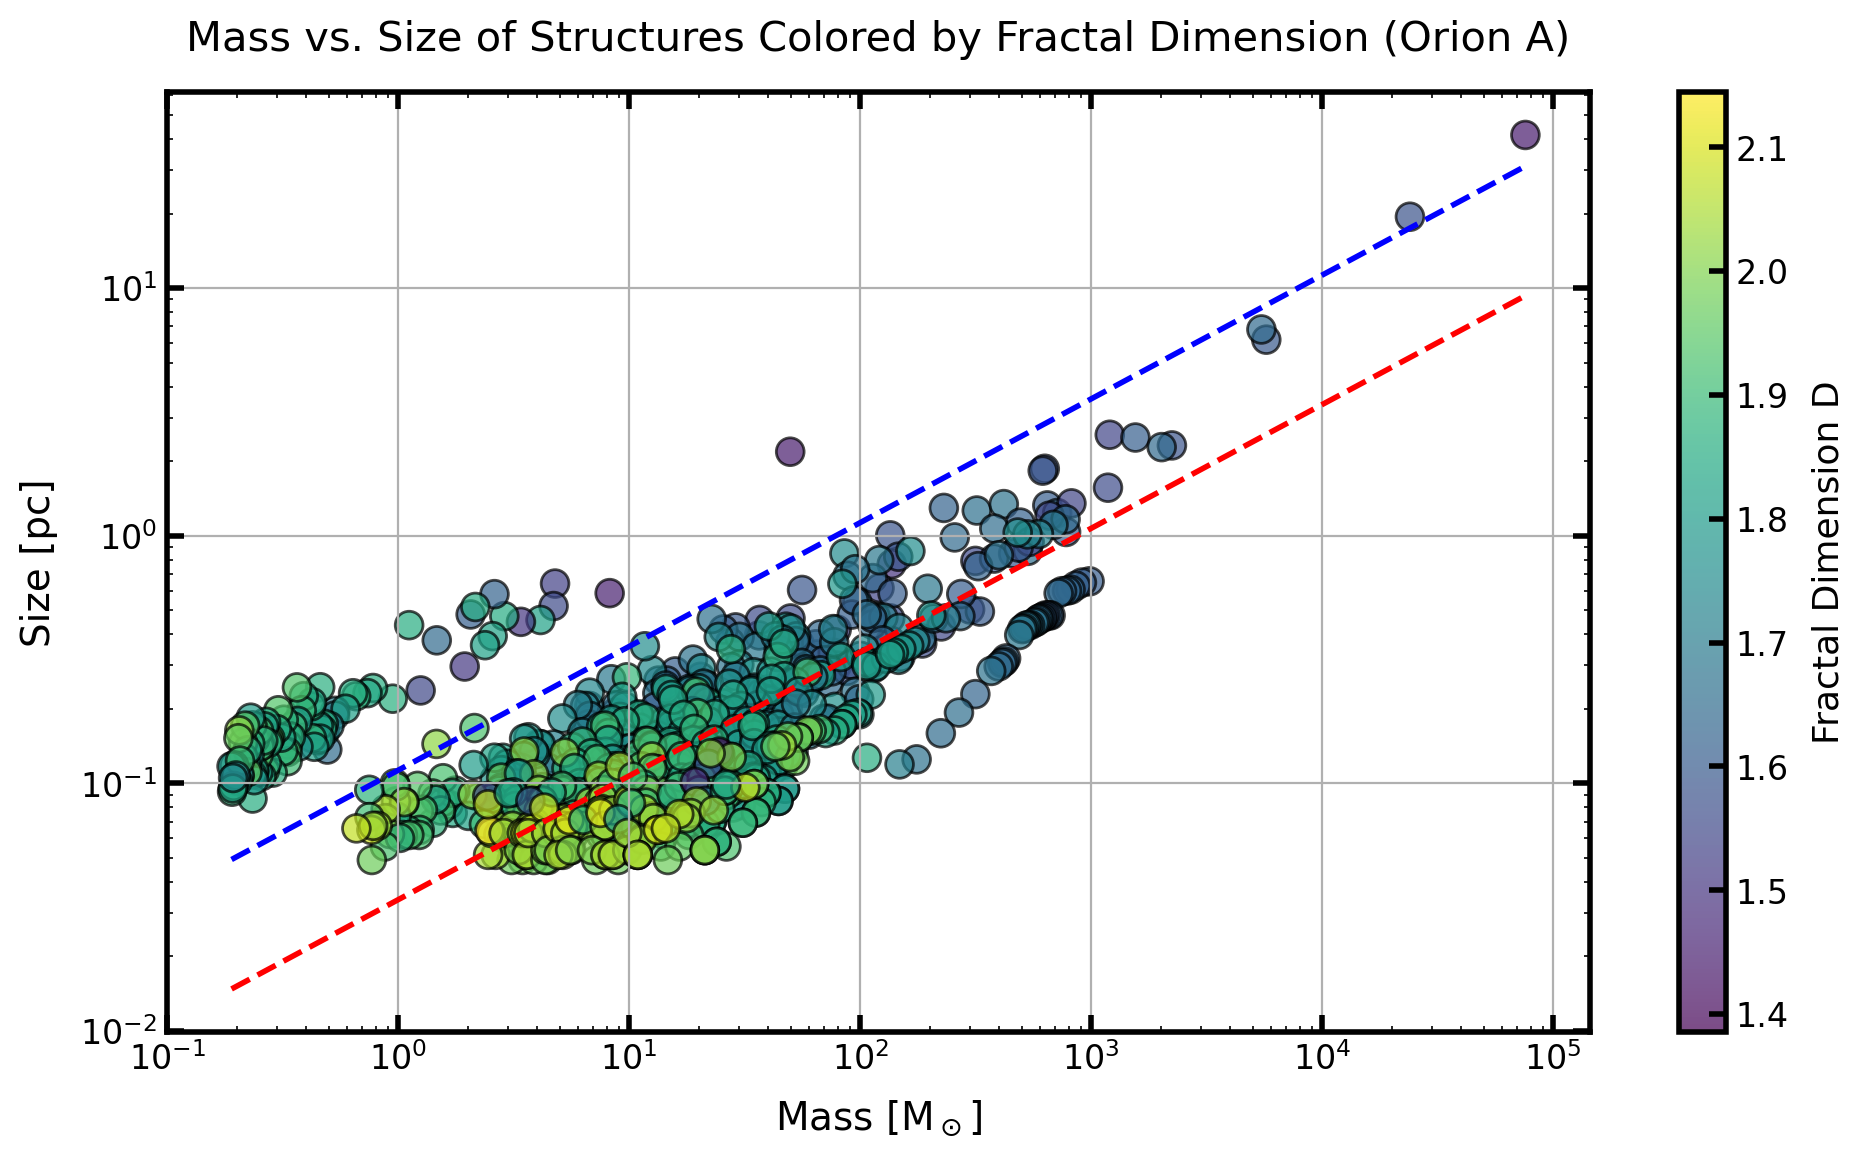

In [110]:
region_masses_OA = np.array(region_masses_OA)
region_sizes_OA = np.array(region_sizes_OA)
region_fractal_dims_OA = np.array(region_fractal_dims_OA)

# mask = (region_fractal_dims_OA >= 1.2) & (region_fractal_dims_OA <= 2.1)
# region_masses_OA = region_masses_OA[mask]
# region_sizes_OA = region_sizes_OA[mask]
# region_fractal_dims_OA = region_fractal_dims_OA[mask]

plt.figure(figsize=(10, 6))

sc = plt.scatter(region_masses_OA, region_sizes_OA, 
                 c=region_fractal_dims_OA, cmap='viridis', alpha=0.7, 
                 s=100, edgecolor='k')

cbar = plt.colorbar(sc)
cbar.set_label("Fractal Dimension D", fontsize=13)

M_min = np.min(region_masses_OA)
M_max = np.max(region_masses_OA)

M = np.logspace(np.log10(M_min), np.log10(M_max), 100)

b0 = 1e4  # cm^(-2)
G = 4.3e-3  # pc M_sun^-1 (km/s)^2
sigma = 2  # Assumed velocity dispersion in km/s (adjust if needed)

# Aspect Ratio 10
A_10 = 10
a_10 = (2 * A_10) / (np.pi * b0) ** 0.5
L_10 = a_10 * M ** 0.5

# Aspect Ratio 3
A_3 = 3
a_3 = (2 * A_3) / (np.pi * b0) ** 0.5
L_3 = a_3 * M ** 0.5

L_vir = (G * M) / (5 * sigma**2)

plt.plot(M, L_10, label="Aspect Ratio=  10", linestyle="--", color="blue")
plt.plot(M, L_3, label="Aspect Ratio = 3", linestyle="--", color="red")

plt.xlabel("Mass [M$_\odot$]", fontsize=14)
plt.ylabel("Size [pc]", fontsize=14)
plt.xscale("log")
plt.yscale("log")
plt.title("Mass vs. Size of Structures Colored by Fractal Dimension (Orion A)", fontsize=15, pad=15)
plt.grid(True)
plt.tight_layout()
plt.show()

<>:43: SyntaxWarning: invalid escape sequence '\o'
<>:43: SyntaxWarning: invalid escape sequence '\o'
C:\Users\User\AppData\Local\Temp\ipykernel_8492\259841693.py:43: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel("Mass [M$_\odot$]", fontsize=14)


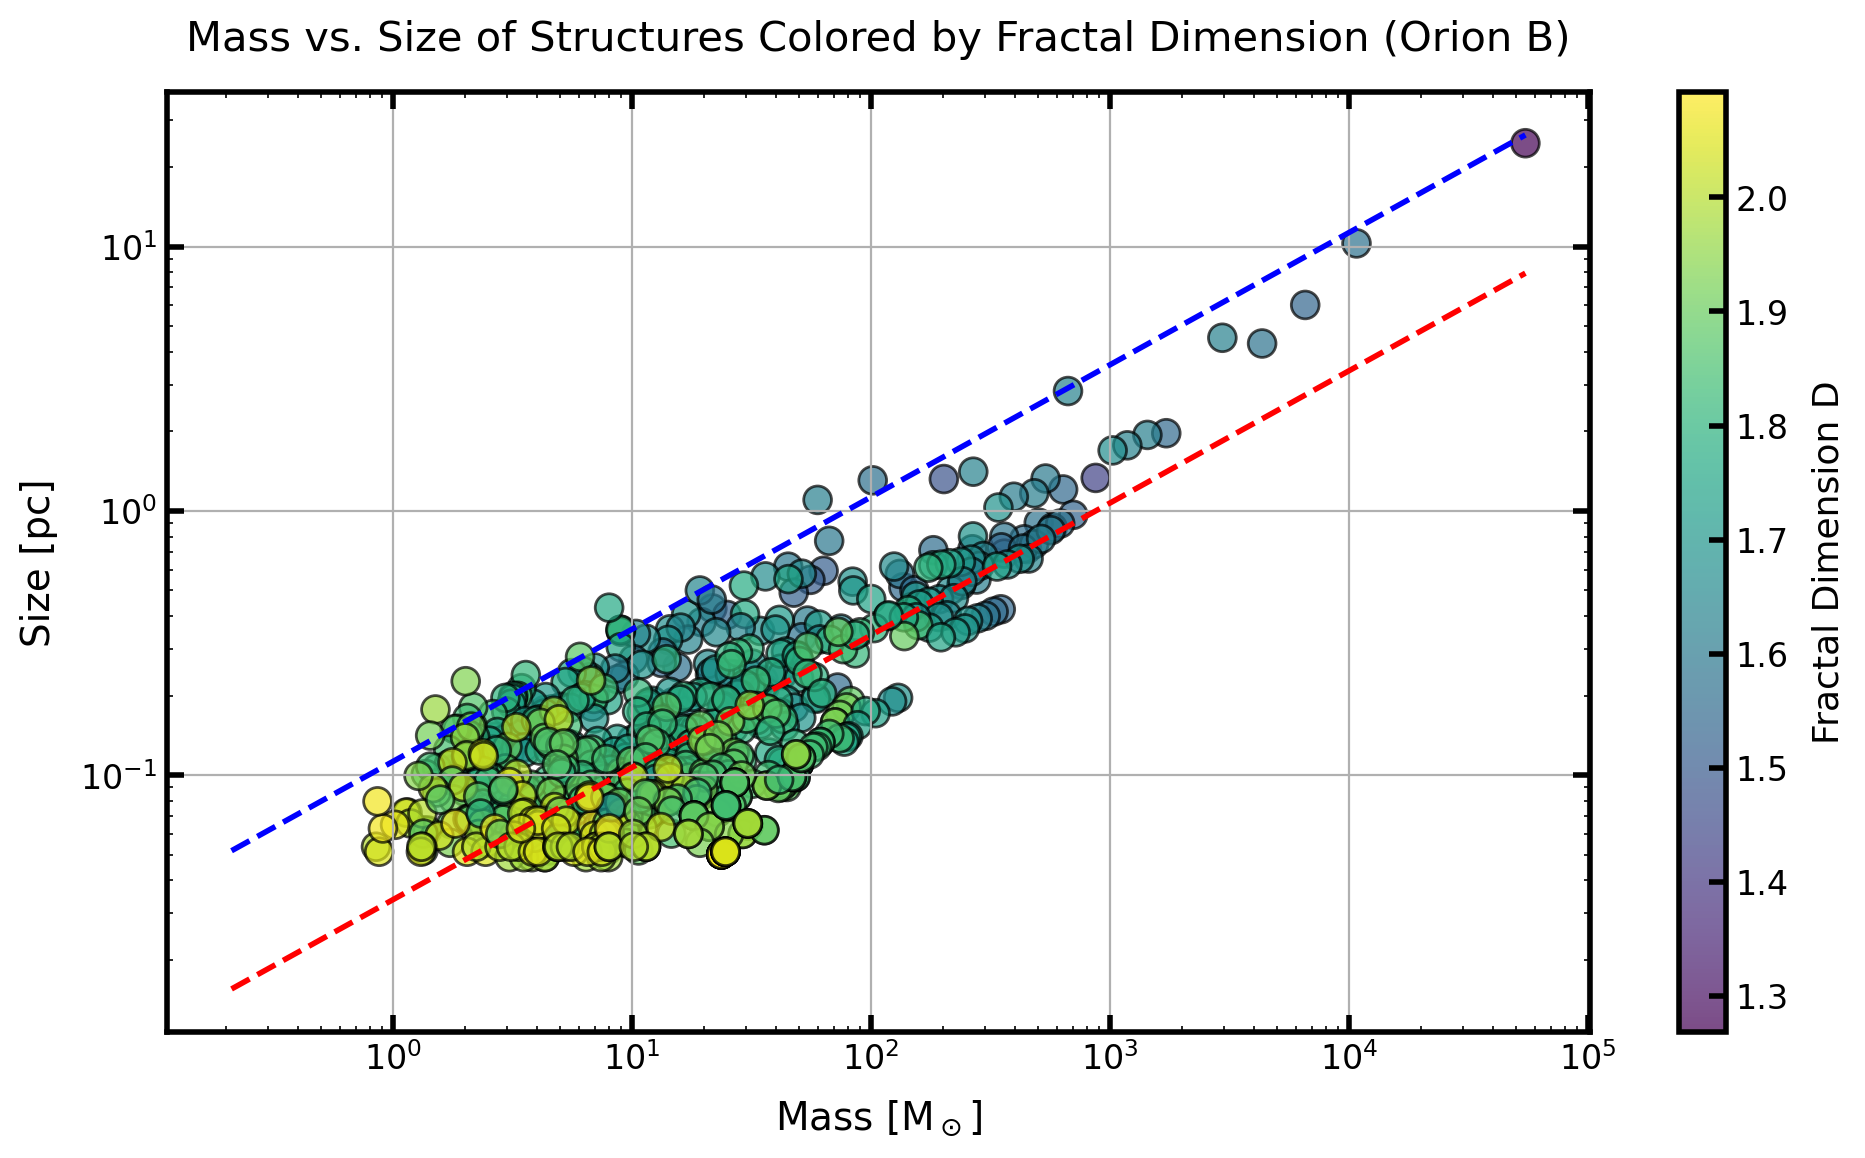

In [111]:
region_masses_OB = np.array(region_masses_OB)
region_sizes_OB = np.array(region_sizes_OB)
region_fractal_dims_OB = np.array(region_fractal_dims_OB)

# mask = (region_fractal_dims_OB >= 1.2) & (region_fractal_dims_OB <= 2.1)
# region_masses_OB = region_masses_OB[mask]
# region_sizes_OB = region_sizes_OB[mask]
# region_fractal_dims_OB = region_fractal_dims_OB[mask]

plt.figure(figsize=(10, 6))

sc = plt.scatter(region_masses_OB, region_sizes_OB, 
                 c=region_fractal_dims_OB, cmap='viridis', alpha=0.7, 
                 s=100, edgecolor='k')

cbar = plt.colorbar(sc)
cbar.set_label("Fractal Dimension D", fontsize=13)

M_min = np.min(region_masses_OB)
M_max = np.max(region_masses_OB)

M = np.logspace(np.log10(M_min), np.log10(M_max), 100)

b0 = 1e4  # cm^(-2)
G = 4.3e-3  # pc M_sun^-1 (km/s)^2
sigma = 2  # Assumed velocity dispersion in km/s (adjust if needed)

# Aspect Ratio 10
A_10 = 10
a_10 = (2 * A_10) / (np.pi * b0) ** 0.5
L_10 = a_10 * M ** 0.5

# Aspect Ratio 3
A_3 = 3
a_3 = (2 * A_3) / (np.pi * b0) ** 0.5
L_3 = a_3 * M ** 0.5

L_vir = (G * M) / (5 * sigma**2)

plt.plot(M, L_10, label="Aspect Ratio=  10", linestyle="--", color="blue")
plt.plot(M, L_3, label="Aspect Ratio = 3", linestyle="--", color="red")

plt.xlabel("Mass [M$_\odot$]", fontsize=14)
plt.ylabel("Size [pc]", fontsize=14)
plt.xscale("log")
plt.yscale("log")
plt.title("Mass vs. Size of Structures Colored by Fractal Dimension (Orion B)", fontsize=15, pad=15)
plt.grid(True)
plt.tight_layout()
plt.show()

<>:59: SyntaxWarning: invalid escape sequence '\o'
<>:59: SyntaxWarning: invalid escape sequence '\o'
C:\Users\User\AppData\Local\Temp\ipykernel_8492\291591904.py:59: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel("Mass [M$_\odot$]", fontsize=14)


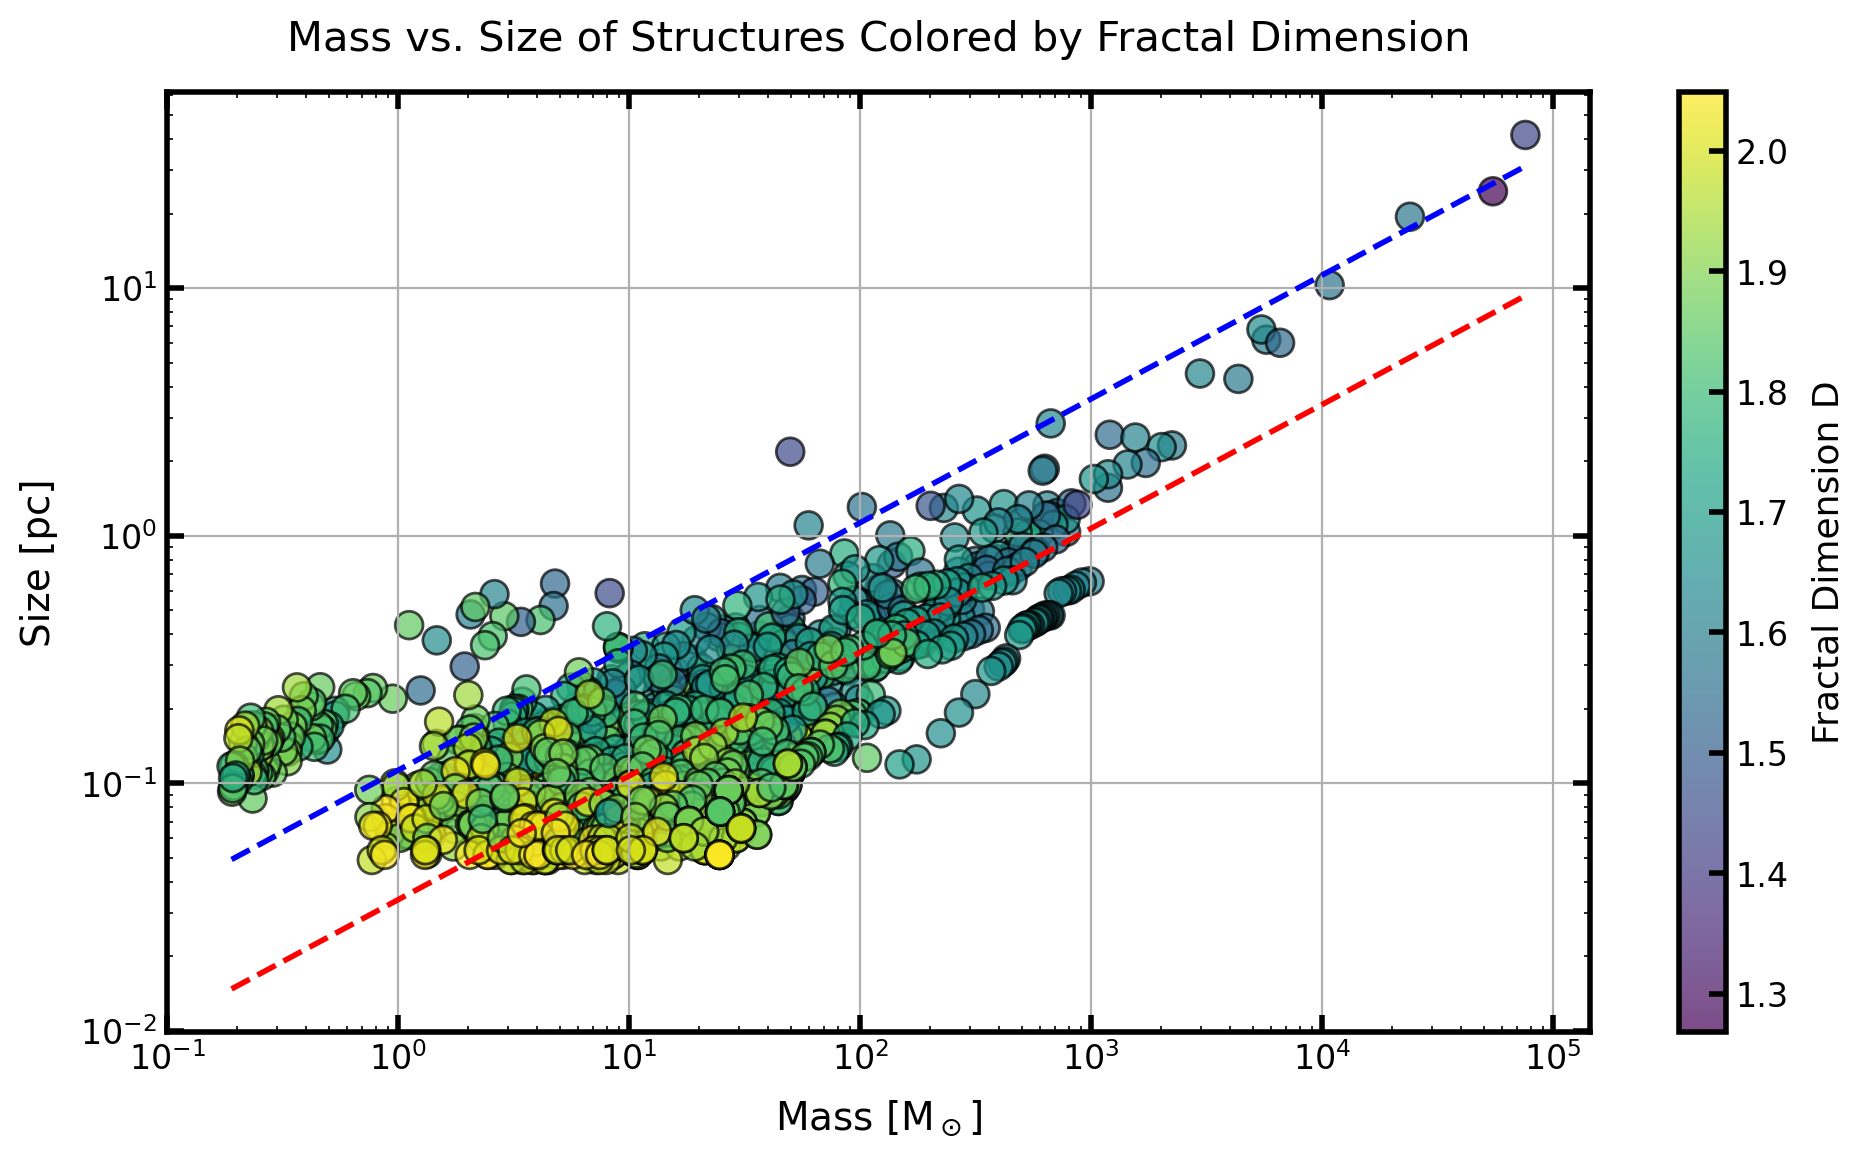

In [115]:
import matplotlib.pyplot as plt
import numpy as np

# Combine region masses, sizes, and fractal dimensions for OA and OB
# region_masses_OA = region_masses_OA.tolist()
# region_masses_OB = region_masses_OB.tolist()
# region_sizes_OA = region_sizes_OA.tolist()
# region_sizes_OB = region_sizes_OB.tolist()
# region_fractal_dims_OA = region_fractal_dims_OA.tolist()
# region_fractal_dims_OB = region_fractal_dims_OB.tolist()

region_masses = region_masses_OA + region_masses_OB
region_sizes = region_sizes_OA + region_sizes_OB
region_fractal_dims = region_fractal_dims_OA + region_fractal_dims_OB

# Remove all entries where mass or size is smaller than 1
region_masses = np.array(region_masses)
region_sizes = np.array(region_sizes)
region_fractal_dims = np.array(region_fractal_dims)

mask = (region_fractal_dims >= 1.2) & (region_fractal_dims <= 2.05)
region_masses = region_masses[mask]
region_sizes = region_sizes[mask]
region_fractal_dims = region_fractal_dims[mask]

plt.figure(figsize=(10, 6))

sc = plt.scatter(region_masses, region_sizes, 
                 c=region_fractal_dims, cmap='viridis', alpha=0.7, 
                 s=100, edgecolor='k')

cbar = plt.colorbar(sc)
cbar.set_label("Fractal Dimension D", fontsize=13)

M_min = np.min(region_masses)
M_max = np.max(region_masses)

M = np.logspace(np.log10(M_min), np.log10(M_max), 100)

b0 = 1e4  # cm^(-2)
G = 4.3e-3  # pc M_sun^-1 (km/s)^2
sigma = 2  # Assumed velocity dispersion in km/s (adjust if needed)

# Aspect Ratio 10
A_10 = 10
a_10 = (2 * A_10) / (np.pi * b0) ** 0.5
L_10 = a_10 * M ** 0.5

# Aspect Ratio 3
A_3 = 3
a_3 = (2 * A_3) / (np.pi * b0) ** 0.5
L_3 = a_3 * M ** 0.5

L_vir = (G * M) / (5 * sigma**2)

plt.plot(M, L_10, label="Aspect Ratio=  10", linestyle="--", color="blue")
plt.plot(M, L_3, label="Aspect Ratio = 3", linestyle="--", color="red")

plt.xlabel("Mass [M$_\odot$]", fontsize=14)
plt.ylabel("Size [pc]", fontsize=14)
plt.xscale("log")
plt.yscale("log")
plt.title("Mass vs. Size of Structures Colored by Fractal Dimension", fontsize=15, pad=15)
plt.grid(True)
plt.tight_layout()
plt.show()

In [116]:
import pyvista as pv
import numpy as np

# Prepare data (use OA as example, or combine OA+OB if desired)
region_masses = np.array(region_masses_OA + region_masses_OB)
region_sizes = np.array(region_sizes_OA + region_sizes_OB)
region_fractal_dims = np.array(region_fractal_dims_OA + region_fractal_dims_OB)

# Remove NaNs and filter for valid fractal dimension range
mask = (~np.isnan(region_fractal_dims)) & (region_fractal_dims >= 1.2) & (region_fractal_dims <= 2.1)
region_masses = region_masses[mask]
region_sizes = region_sizes[mask]
region_fractal_dims = region_fractal_dims[mask]

# Log scale for mass and size for better visualization
points = np.column_stack((np.log10(region_masses), np.log10(region_sizes), region_fractal_dims))

cloud = pv.PolyData(points)
plotter = pv.Plotter()
plotter.add_points(cloud, render_points_as_spheres=True, point_size=6, scalars=region_fractal_dims, cmap="viridis")
plotter.set_background("white")

labels = dict(zlabel='D', xlabel='log10(Mass)', ylabel='log10(Size)')

plotter.add_axes(**labels)
plotter.show_grid(**labels)
plotter.add_title("Mass-Size-D Plane")
plotter.show()

c:\Users\User\anaconda3\envs\Astronomy_Env\Lib\site-packages\pyvista\plotting\renderer.py:1846: PyVistaDeprecationWarning: `xlabel` is deprecated. Use `xtitle` instead.
  warnings.warn(
c:\Users\User\anaconda3\envs\Astronomy_Env\Lib\site-packages\pyvista\plotting\renderer.py:1852: PyVistaDeprecationWarning: `ylabel` is deprecated. Use `ytitle` instead.
  warnings.warn(
c:\Users\User\anaconda3\envs\Astronomy_Env\Lib\site-packages\pyvista\plotting\renderer.py:1858: PyVistaDeprecationWarning: `zlabel` is deprecated. Use `ztitle` instead.
  warnings.warn(


Widget(value='<iframe src="http://localhost:65019/index.html?ui=P_0x1c481f70bc0_19&reconnect=auto" class="pyvi…